In [1]:
import pandas as pd
import numpy as np
import psycopg2


In [2]:
import matplotlib.pyplot as plt

In [30]:
import seaborn as sns

# Dataset

O dataset foi obtido diretamente da base de dados

In [3]:
DB_CONFIG = {
    'host': 'localhost',
    'port': 5432,
    'database': 'labdb',
    'user': 'labuser',
    'password': 'labpass'
}

In [4]:
class PostgresDatabase:
    """Class responsible for PostgreSQL connection management."""

    def __init__(self, db_config):
        self.config = db_config
        self.connection = None

    def connect(self):
        if self.connection is None:
            self.connection = psycopg2.connect(
                host=self.config['host'],
                port=self.config['port'],
                dbname=self.config['database'],
                user=self.config['user'],
                password=self.config['password']
            )
            print(f"Connected to database: {self.config['database']}")
        return self.connection

    def close(self):
        if self.connection:
            self.connection.close()
            self.connection = None
            print("Connection closed.")

In [5]:
class PostgresExecutor:
    """Class responsible for SQL operations."""

    def __init__(self, connection):
        self.connection = connection

    def fetch(self, query, params=None):
        cursor = self.connection.cursor()
        cursor.execute(query, params)
        results = cursor.fetchall()
        columns = [desc[0] for desc in cursor.description]
        cursor.close()
        return results, columns

In [6]:
db = PostgresDatabase(DB_CONFIG)
connection = db.connect()
executor = PostgresExecutor(connection)

rows, columns = executor.fetch('SELECT * FROM diabetes')
df = pd.DataFrame(rows, columns=columns)

print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Connected to database: labdb
Dataset loaded: 771 rows, 14 columns


,id,pregnancies,glucose,blood_pressure,skin_thickness,insulin,body_mass_index,diabetes_pedigree_function,age,outcome,clinic_region,care_path,patient_segment,source_file
0,1,6,148.0,72.0,35.0,NaN,NaN,0.627,50.0,Positive,North,High-Risk,Adult,diabetes-dirty.csv
1,2,1,85.0,66.0,29.0,NaN,26.6,0.351,31.0,Negative,South,Routine Follow-up,Senior,diabetes-dirty.csv
2,3,8,183.0,64.0,NaN,NaN,23.3,0.672,32.0,Positive,North,Urgent Monitoring,Mid-Age,diabetes-dirty.csv
3,4,1,89.0,66.0,23.0,94.0,28.1,0.167,21.0,Negative,South,Routine Follow-up,NaN,diabetes-dirty.csv
4,5,0,137.0,40.0,35.0,168.0,43.1,2.288,33.0,Positive,NaN,NaN,Adult,diabetes-dirty.csv


In [7]:
df = pd.DataFrame(rows, columns=columns)
df = df.set_index('id')
df

,pregnancies,glucose,blood_pressure,skin_thickness,insulin,body_mass_index,diabetes_pedigree_function,age,outcome,clinic_region,care_path,patient_segment,source_file
id,,,,,,,,,,,,,
1,6,148.0,72.0,35.0,NaN,NaN,0.627,50.0,Positive,North,High-Risk,Adult,diabetes-dirty.csv
2,1,85.0,66.0,29.0,NaN,26.6,0.351,31.0,Negative,South,Routine Follow-up,Senior,diabetes-dirty.csv
3,8,183.0,64.0,NaN,NaN,23.3,0.672,32.0,Positive,North,Urgent Monitoring,Mid-Age,diabetes-dirty.csv
4,1,89.0,66.0,23.0,94.0,28.1,0.167,21.0,Negative,South,Routine Follow-up,NaN,diabetes-dirty.csv
5,0,137.0,40.0,35.0,168.0,43.1,2.288,33.0,Positive,NaN,NaN,Adult,diabetes-dirty.csv
...,...,...,...,...,...,...,...,...,...,...,...,...,...
767,1,126.0,NaN,NaN,NaN,30.1,0.349,NaN,Negative,North,Routine Follow-up,Adult,diabetes-dirty.csv
768,1,NaN,70.0,31.0,NaN,30.4,0.315,23.0,Positive,South,Routine Follow-up,Adult,diabetes-dirty.csv
769,1,89.0,66.0,23.0,94.0,28.1,0.167,21.0,Negative,South,Routine Follow-up,NaN,diabetes-dirty.csv


In [8]:
df.shape

(771, 13)

# Check for missing values

In [9]:
df.isnull().sum()

pregnancies                     0
glucose                        82
blood_pressure                105
skin_thickness                228
insulin                       404
body_mass_index               110
diabetes_pedigree_function      0
age                            62
outcome                        43
clinic_region                  47
care_path                     211
patient_segment                68
source_file                     0
dtype: int64

In [10]:
print("Colunas mais problemáticas:")
missing = df.isnull().sum()
print(missing[missing > 0].sort_values(ascending=False))

Colunas mais problemáticas:
insulin            404
skin_thickness     228
care_path          211
body_mass_index    110
blood_pressure     105
glucose             82
patient_segment     68
age                 62
clinic_region       47
outcome             43
dtype: int64


In [11]:
def percentage_missing_values(df, col):
    missing_count = df[col].isnull().sum()
    total_rows = len(df)
    percentage = (missing_count / total_rows) * 100
    return percentage

In [12]:
insulin  = percentage_missing_values(df, 'insulin')
print(f"Percentagem de valores faltantes em 'insulin': {insulin:.2f}%")

skin_thickness = percentage_missing_values(df, 'skin_thickness')
print(f"Percentagem de valores faltantes em 'skin thickness': {skin_thickness:.2f}%")

blood_pressure = percentage_missing_values(df, 'blood_pressure')
print(f"Percentagem de valores faltantes em 'blood pressure': {blood_pressure:.2f}%")

patient_segment = percentage_missing_values(df, 'patient_segment')
print(f"Percentagem de valores faltantes em 'patient segment': {patient_segment:.2f}%")

age = percentage_missing_values(df, 'age')
print(f"Percentagem de valores faltantes em 'age': {age:.2f}%")

glucose = percentage_missing_values(df, 'glucose')
print(f"Percentagem de valores faltantes em 'glucose': {glucose:.2f}%")

body_mass_index = percentage_missing_values(df, 'body_mass_index')
print(f"Percentagem de valores faltantes em 'body mass index': {body_mass_index:.2f}%")

care_path = percentage_missing_values(df, 'care_path')
print(f"Percentagem de valores faltantes em 'care path': {care_path:.2f}%")

clinic_region = percentage_missing_values(df, 'clinic_region')
print(f"Percentagem de valores faltantes em 'care path': {clinic_region:.2f}%")

outcome = percentage_missing_values(df, 'outcome')
print(f"Percentagem de valores faltantes em 'outcome': {outcome:.2f}%")

Percentagem de valores faltantes em 'insulin': 52.40%
Percentagem de valores faltantes em 'skin thickness': 29.57%
Percentagem de valores faltantes em 'blood pressure': 13.62%
Percentagem de valores faltantes em 'patient segment': 8.82%
Percentagem de valores faltantes em 'age': 8.04%
Percentagem de valores faltantes em 'glucose': 10.64%
Percentagem de valores faltantes em 'body mass index': 14.27%
Percentagem de valores faltantes em 'care path': 27.37%
Percentagem de valores faltantes em 'care path': 6.10%
Percentagem de valores faltantes em 'outcome': 5.58%


##  Missing value imputation

#### Impute missing values for numerical columns

In [13]:
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()
print(numerical_columns)

['pregnancies', 'glucose', 'blood_pressure', 'skin_thickness', 'insulin', 'body_mass_index', 'diabetes_pedigree_function', 'age']


In [14]:
df[numerical_columns] = df[numerical_columns].fillna(df[numerical_columns].median())

In [15]:
# Verify whether missing values still exist
df.isnull().sum()

pregnancies                     0
glucose                         0
blood_pressure                  0
skin_thickness                  0
insulin                         0
body_mass_index                 0
diabetes_pedigree_function      0
age                             0
outcome                        43
clinic_region                  47
care_path                     211
patient_segment                68
source_file                     0
dtype: int64

#### Impute missing values for categorical columns

In [16]:
categorical_columns = df.select_dtypes(include='object').columns.tolist()
print(categorical_columns)

['outcome', 'clinic_region', 'care_path', 'patient_segment', 'source_file']


/var/folders/rc/98dfkj2x429dbn7n7sx100200000gp/T/ipykernel_10401/3016867992.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include='object').columns.tolist()


In [17]:
def impute_categorical(df, columns):
    for col in columns:
        mode = df[col].mode()
        if len(mode) > 0:
            df[col] = df[col].fillna(mode[0])
        else:
            df[col] = df[col].fillna('unknown')
    return df

df = impute_categorical(df, categorical_columns)

In [18]:
df.isnull().sum()

pregnancies                   0
glucose                       0
blood_pressure                0
skin_thickness                0
insulin                       0
body_mass_index               0
diabetes_pedigree_function    0
age                           0
outcome                       0
clinic_region                 0
care_path                     0
patient_segment               0
source_file                   0
dtype: int64

In [19]:
int_columns = ['pregnancies', 'glucose', 'blood_pressure', 'skin_thickness', 'insulin', 'age']
df[int_columns] = df[int_columns].astype(int)

# Duplicates and outliers

In [20]:
dups = df.duplicated().sum()
print(f"Total de linhas duplicadas no df: {dups}")

Total de linhas duplicadas no df: 3


In [21]:
if dups > 0:
    print("Linhas duplicadas:")
    display(df[df.duplicated(keep=False)].sort_values(by=list(df.columns)))

Linhas duplicadas:


,pregnancies,glucose,blood_pressure,skin_thickness,insulin,body_mass_index,diabetes_pedigree_function,age,outcome,clinic_region,care_path,patient_segment,source_file
id,,,,,,,,,,,,,
4,1,89,66,23,94,28.1,0.167,21,Negative,South,Routine Follow-up,Adult,diabetes-dirty.csv
769,1,89,66,23,94,28.1,0.167,21,Negative,South,Routine Follow-up,Adult,diabetes-dirty.csv
28,1,119,72,15,140,32.4,0.487,22,Negative,South,Routine Follow-up,Adult,diabetes-dirty.csv
771,1,119,72,15,140,32.4,0.487,22,Negative,South,Routine Follow-up,Adult,diabetes-dirty.csv
16,7,100,72,29,126,30.0,0.484,32,Positive,South,Routine Follow-up,Adult,diabetes-dirty.csv
770,7,100,72,29,126,30.0,0.484,32,Positive,South,Routine Follow-up,Adult,diabetes-dirty.csv


In [22]:
#### Remove duplicated rows 
df = df.drop_duplicates()

### Verifying if there are **outliers** in numerical columns 

In [23]:
def verify_outliers(df: pd.DataFrame, col: str) -> bool:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    outlier_report = {}

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
        
        
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_report[col] = len(outliers)
        
    if len(outliers) > 0:
        print(f"Coluna '{col}': {len(outliers)} outliers detectados (Limites: {lower_bound:.2f} a {upper_bound:.2f})")
        display(outliers[[col]])
            
    return outlier_report

In [24]:
for coluna in numerical_columns:
    resultado = verify_outliers(df, coluna)

Coluna 'pregnancies': 4 outliers detectados (Limites: -6.50 a 13.50)


,pregnancies
id,
89,15
160,17
299,14
456,14


Coluna 'glucose': 25 outliers detectados (Limites: 45.00 a 197.00)


,glucose
id,
11,999
54,528
62,399
63,44
99,279
141,384
203,324
236,513
237,543


Coluna 'blood_pressure': 25 outliers detectados (Limites: 47.38 a 96.38)


...

,body_mass_index
id,
54,84.25
62,82.25
85,48.80
99,71.75
100,49.70
121,53.20
126,55.00
141,52.75
155,47.90


Coluna 'diabetes_pedigree_function': 29 outliers detectados (Limites: -0.33 a 1.20)


,diabetes_pedigree_function
id,
5,2.288
13,1.441
40,1.390
46,1.893
59,1.781
101,1.222
148,1.400
188,1.321
219,1.224


Coluna 'age': 48 outliers detectados (Limites: 1.00 a 65.00)


,age
id,
19,396
31,720
45,150
57,492
124,69
125,276
127,360
132,396
174,276


In [25]:
# Remove rows with glucose above 200
df = df[df['glucose'] <= 200]

# Remove rows with impossible age values
df = df[df['age'] < 120]

In [26]:
df

,pregnancies,glucose,blood_pressure,skin_thickness,insulin,body_mass_index,diabetes_pedigree_function,age,outcome,clinic_region,care_path,patient_segment,source_file
id,,,,,,,,,,,,,
1,6,148,72,35,126,32.4,0.627,50,Positive,North,High-Risk,Adult,diabetes-dirty.csv
2,1,85,66,29,126,26.6,0.351,31,Negative,South,Routine Follow-up,Senior,diabetes-dirty.csv
3,8,183,64,29,126,23.3,0.672,32,Positive,North,Urgent Monitoring,Mid-Age,diabetes-dirty.csv
4,1,89,66,23,94,28.1,0.167,21,Negative,South,Routine Follow-up,Adult,diabetes-dirty.csv
5,0,137,40,35,168,43.1,2.288,33,Positive,South,Routine Follow-up,Adult,diabetes-dirty.csv
...,...,...,...,...,...,...,...,...,...,...,...,...,...
763,9,119,62,29,126,32.4,0.142,33,Negative,North,Routine Follow-up,Adult,diabetes-dirty.csv
764,10,101,76,48,180,32.9,0.171,63,Negative,South,Routine Follow-up,Adult,diabetes-dirty.csv
765,2,122,70,27,126,36.8,0.340,27,Negative,North,Routine Follow-up,Adult,diabetes-dirty.csv


# Distribuição 

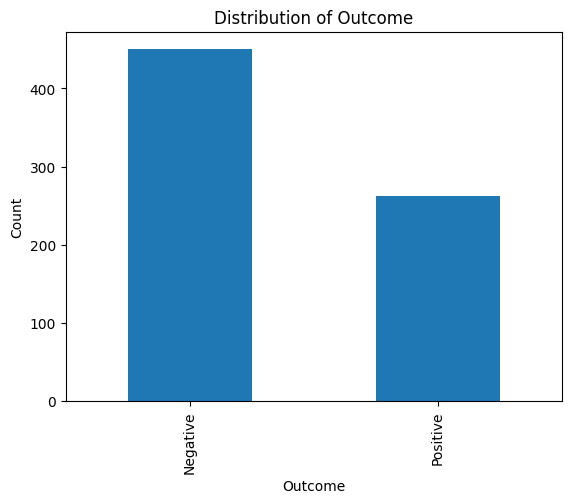

In [27]:
df['outcome'].value_counts().plot(kind='bar')
plt.title('Distribution of Outcome')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.show()

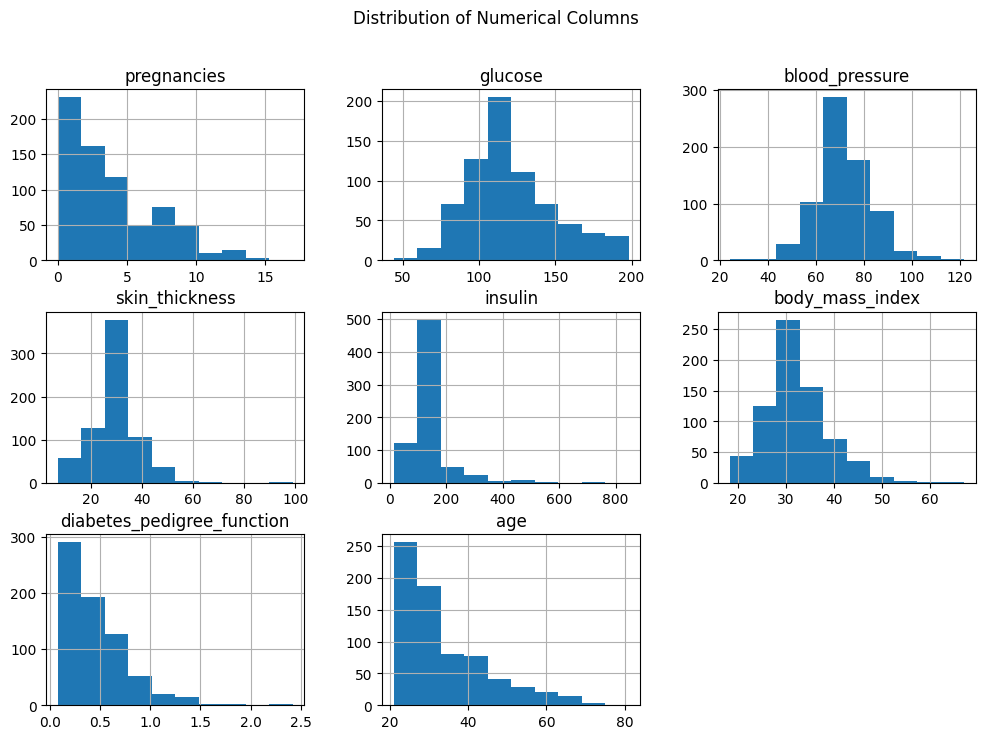

In [28]:
df[numerical_columns].hist(figsize=(12, 8))
plt.suptitle('Distribution of Numerical Columns')
plt.show()

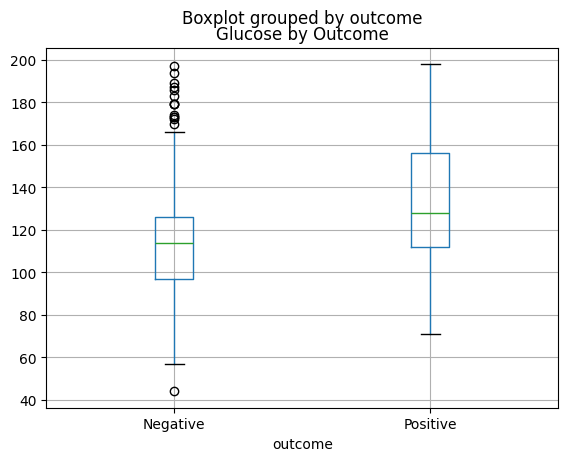

In [29]:
df.boxplot(column='glucose', by='outcome')
plt.title('Glucose by Outcome')
plt.show()

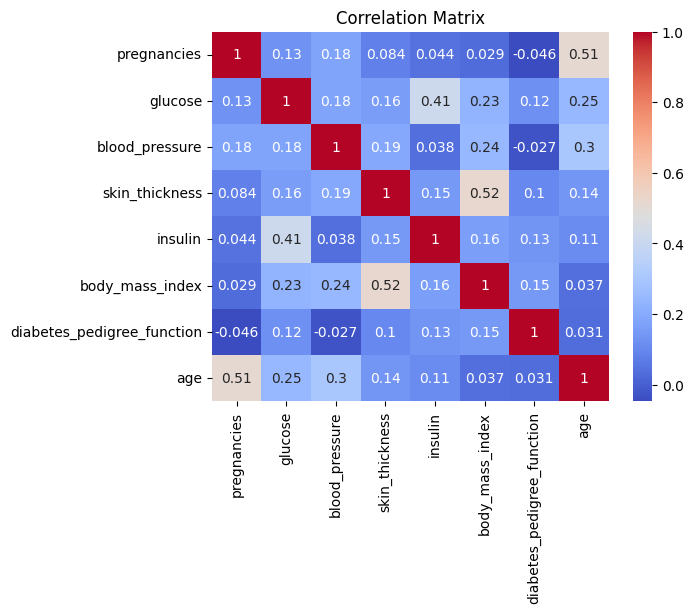

In [31]:
sns.heatmap(df[numerical_columns].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()